In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
import pandas as pd

matches= pd.read_csv('df_match.csv')

# Remove duplicates
matches.drop_duplicates(inplace=True)

# Handle missing values
matches.fillna('Unknown', inplace=True)

# Convert date column
matches['matchDate'] = pd.to_datetime(matches['matchDate'],dayfirst=True,errors='coerce')

# Standardize team names
matches['team1'] = matches['team1'].str.strip()
matches['team2'] = matches['team2'].str.strip()



matches.head()

,team1,team2,winner,margin,ground,matchDate,match_id
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,2022-10-16,T20I # 1823
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,2022-10-16,T20I # 1825
2,Scotland,West Indies,Scotland,42 runs,Hobart,2022-10-17,T20I # 1826
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,2022-10-17,T20I # 1828
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,2022-10-18,T20I # 1830


In [29]:
import pandas as pd

batting = pd.read_csv('df_batting.csv')

# Remove duplicates
batting.drop_duplicates(inplace=True)

# Fill missing values
batting.fillna(0, inplace=True)

# Convert numeric columns
batting['runs'] = batting['runs'].astype(int)
batting['balls'] = batting['balls'].astype(int)

# Create strike rate column if not present
batting['strike_rate'] = (
    batting['runs'] / batting['balls']
) * 100

# Handle division by zero
batting['strike_rate'] = batting['strike_rate'].fillna(0)

batting.head()

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not_out,match_id,strike_rate
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,out,T20I # 1823,50.000000
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,out,T20I # 1823,100.000000
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,out,T20I # 1823,166.666667
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,out,T20I # 1823,108.333333
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,out,T20I # 1823,83.333333


In [30]:
import pandas as pd

bowling = pd.read_csv('df_bowling.csv')

# Remove duplicates
bowling.drop_duplicates(inplace=True)

# Fill missing values
bowling.fillna(0, inplace=True)

# Convert numeric columns
bowling['wickets'] = bowling['wickets'].astype(int)
bowling['overs'] = bowling['overs'].astype(float)

# Create economy rate if not present
bowling['economy'] = (
    bowling['runs'] / bowling['overs']
)


# Handle division by zero
bowling['economy'] = bowling['economy'].fillna(0)
bowling.head()

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,match_id
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,4.0,0,23,1,5.75,7,0,0,2,0,T20I # 1823
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,4.0,0,39,1,9.75,6,3,1,2,0,T20I # 1823
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,4.0,0,37,2,9.25,6,3,1,0,0,T20I # 1823
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,4.0,0,36,1,9.00,7,3,1,1,0,T20I # 1823
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,4.0,0,27,1,6.75,8,1,1,0,0,T20I # 1823


In [31]:
import os

os.makedirs('cleaned_data', exist_ok=True)

matches.to_csv('cleaned_data/cleaned_df_match.csv', index=False)
batting.to_csv('cleaned_data/cleaned_df_batting.csv', index=False)
bowling.to_csv('cleaned_data/cleaned_df_bowling.csv', index=False)

print('Data Cleaning Completed Successfully')

Data Cleaning Completed Successfully


In [32]:
team_wins = matches['winner'].value_counts()
print(team_wins)



winner
England         5
Pakistan        4
Netherlands     4
India           4
Sri Lanka       4
abandoned       3
New Zealand     3
Zimbabwe        3
Ireland         3
Australia       3
South Africa    2
Bangladesh      2
Namibia         1
U.A.E.          1
West Indies     1
Scotland        1
no result       1
Name: count, dtype: int64


In [33]:
# Top Run Scorers
runs = batting.groupby('batsmanName')['runs'].sum().sort_values(ascending=False).head(10)




In [34]:
wickets = bowling.groupby('bowlerName')['wickets'].sum().sort_values(ascending=False).head(10)

In [35]:
most_sixes=batting.groupby('batsmanName')['6s'].sum().sort_values(ascending=False).head(10)

VISUALISATION OF STATS

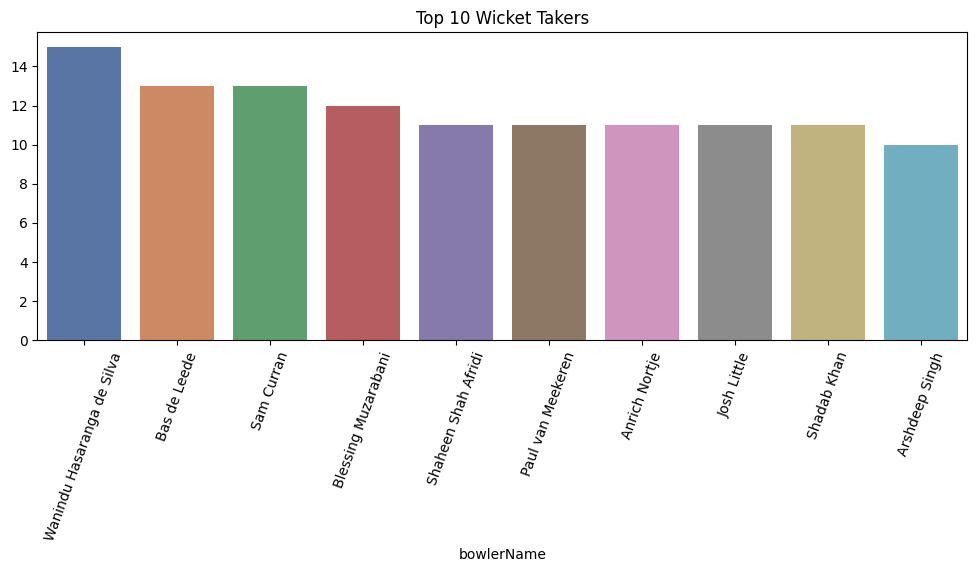

In [36]:
plt.figure(figsize=(12,4))

sns.barplot(
    x=wickets.index,
    y=wickets.values,
    hue=wickets.index,
    legend=False,
    palette='deep'
)

plt.title('Top 10 Wicket Takers')

plt.xticks(rotation=70)

plt.show()


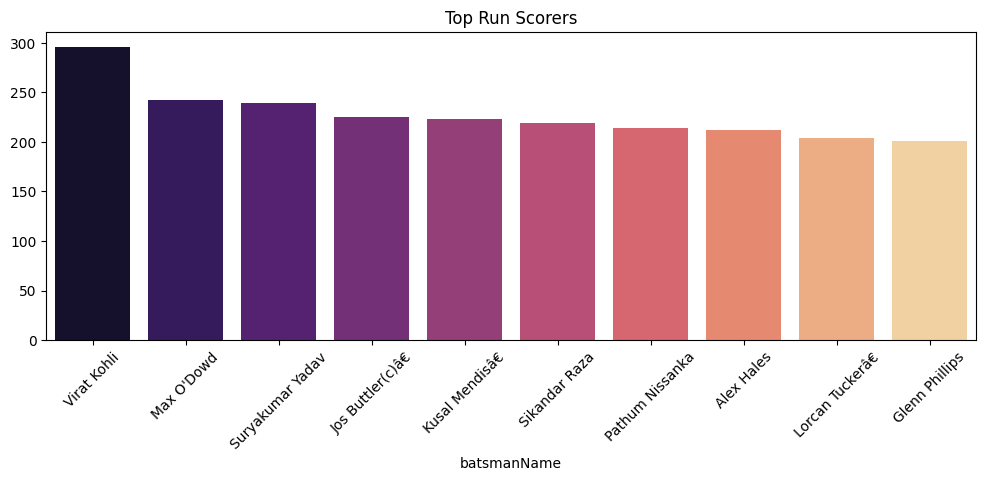

In [37]:
plt.figure(figsize=(12,4))

sns.barplot(
    x=runs.index,
    y=runs.values,
    hue=runs.index,
    legend=False,
    palette='magma'
    
)

plt.title('Top Run Scorers')

plt.xticks(rotation=45)

plt.show()

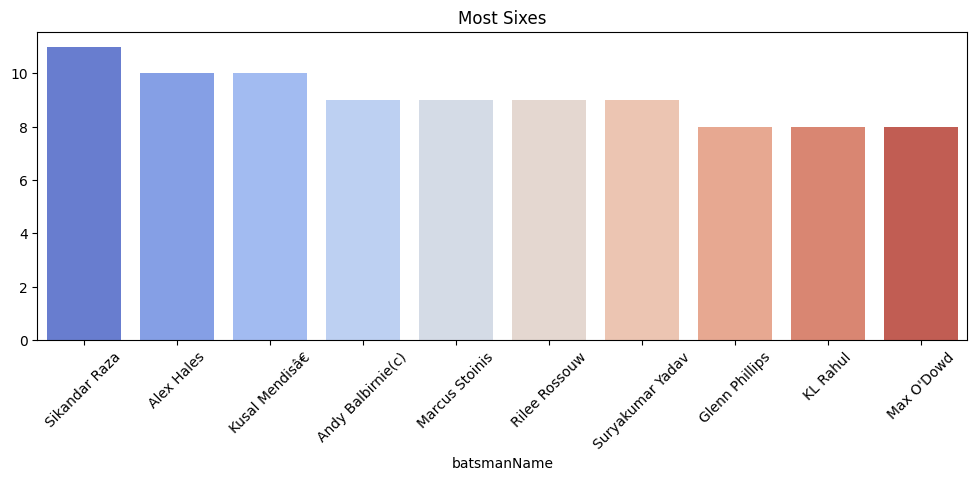

In [38]:
plt.figure(figsize=(12,4))

sns.barplot(
    x=most_sixes.index,
    y=most_sixes.values,
    hue=most_sixes.index,
    legend=False,
    palette='coolwarm'
)

plt.title('Most Sixes')

plt.xticks(rotation=45)

plt.show()


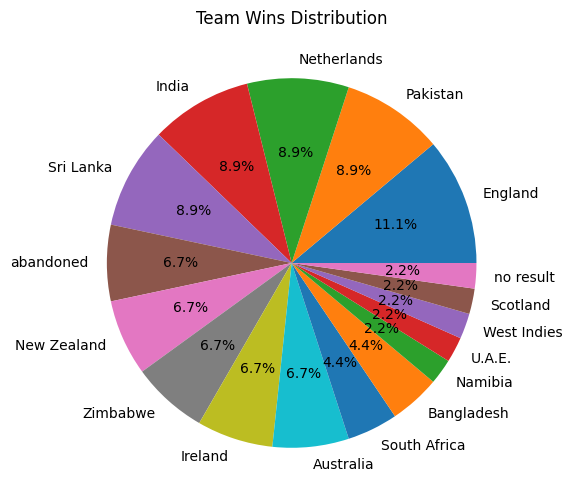

In [39]:
plt.figure(figsize=(12,6))

plt.pie(
    team_wins,
    labels=team_wins.index,
    autopct='%1.1f%%'
)

plt.title('Team Wins Distribution')

plt.show()

In [40]:
batting['SR'] = pd.to_numeric(batting['SR'],errors='coerce')

strike_rate= batting.groupby('batsmanName')['SR'].mean().sort_values(ascending=False).head(10)



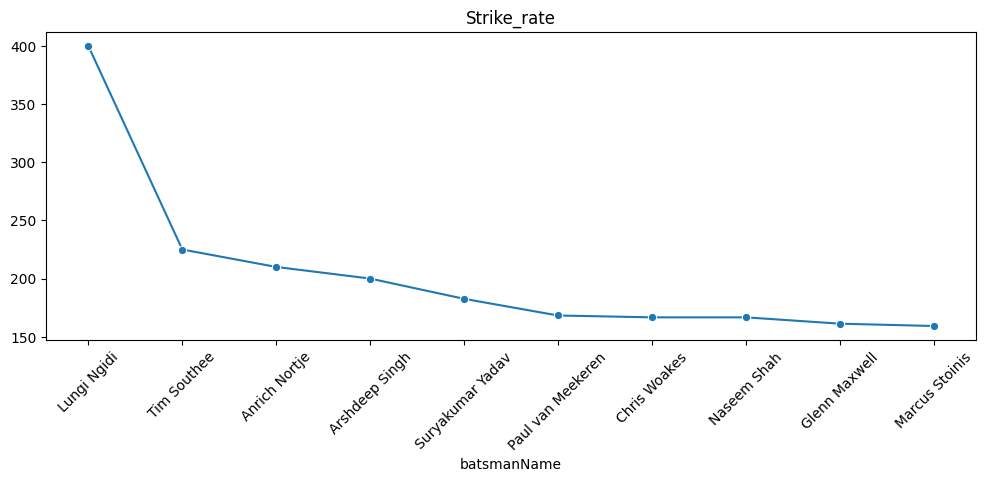

In [41]:
plt.figure(figsize=(12,4))

sns.lineplot(
    x=strike_rate.index,
    y=strike_rate.values,
    marker="o"
)

plt.title('Strike_rate')

plt.xticks(rotation=45)

plt.show()

In [42]:
bowler_economy=bowling.groupby('bowlerName')['economy'].mean().sort_values(ascending=False).head(10)

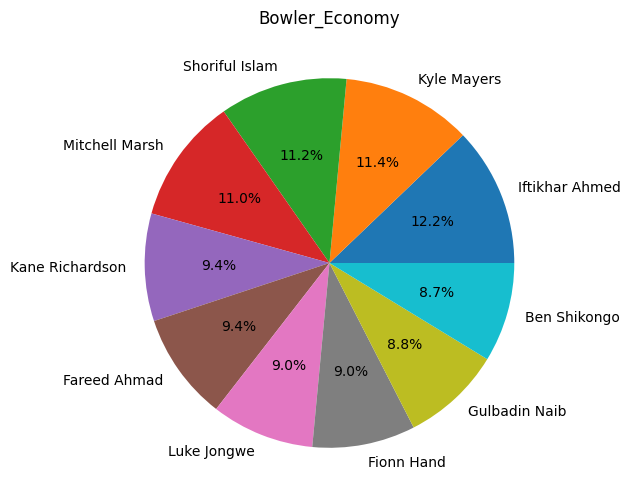

In [43]:
plt.figure(figsize=(12,6))

plt.pie(
   bowler_economy,
   labels=bowler_economy.index,
   autopct='%1.1f%%'
)

plt.title('Bowler_Economy')

plt.xticks(rotation=45)

plt.show()

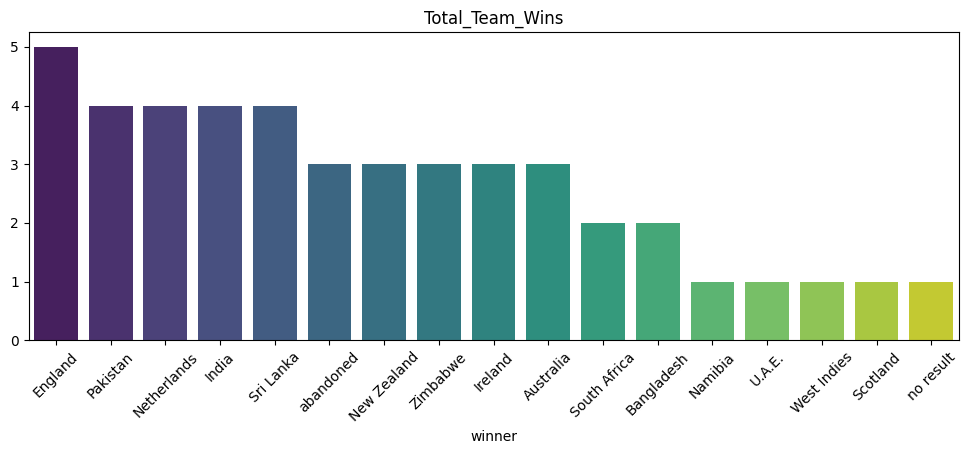

In [44]:
plt.figure(figsize=(12,4))
sns.barplot(
    x=team_wins.index,
    y=team_wins.values,
    hue=team_wins.index,
    legend=False,
    palette='viridis'
)

plt.title('Total_Team_Wins')
plt.xticks(rotation=45)
plt.show()